# Week 13 — Function 05

Focused, checksum-backed review of verified evidence through Week 11. No authoritative Week 12 or Week 13 returned output is treated as an observation.

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reviews one black-box function, presents bounded EDA, and surfaces the exact canonical Week 13 GP-UCB recommendation.

<a id="objectives"></a>
## 2. Objectives

Validate the cumulative evidence, describe the observed search history, inspect diagnostics, report the fitted GP configuration, and verify the proposed query.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

Starter observations are combined only with returned pairs in the immutable canonical ledger. Missing Week 12 and Week 13 returns are not imputed.

<a id="environment-setup"></a>
## 4. Environment and setup

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown
repo_root=Path.cwd().resolve()
while not (repo_root/'Code').exists() and repo_root!=repo_root.parent: repo_root=repo_root.parent
function_root=repo_root/'Week_13'/'Function_05'
sys.path.insert(0,str(function_root/'02_Code'))
from analyse_week_13_function_05 import analyse


<a id="data-validation"></a>
## 5. Data validation

Reconstruct the function data and validate its recorded summary before analysis.

{'week': 13,
 'function': 5,
 'dimensions': 4,
 'starter_observations': 20,
 'recorded_pairs': 11,
 'total_verified_observations': 31,
 'best_query': 28,
 'best_input': [0.08123, 0.992582, 0.156202, 0.988421],
 'best_output': 1465.5121917504077,
 'latest_verified_query': 31,
 'latest_verified_input': [0.016444, 0.027486, 0.656999, 0.955172],
 'latest_verified_output': 210.03831315192616,
 'latest_improves_previous_best': False,
 'minimum_output': 0.1129397953712203,
 'mean_output': 333.08634963315325,
 'standard_deviation': 443.40799477685977,
 'evidence_gap': 'No verified Week 12 or Week 13 return is present; confirmed cumulative evidence is available through Week 11.',
 'interpretation': 'Within-function descriptive evidence; no causal or cross-function ranking claim.',
 'archive_integrity': 'Original repository Week 11 arrays remain quarantined; analysis uses independently recovered pairs from the canonical ledger.'}

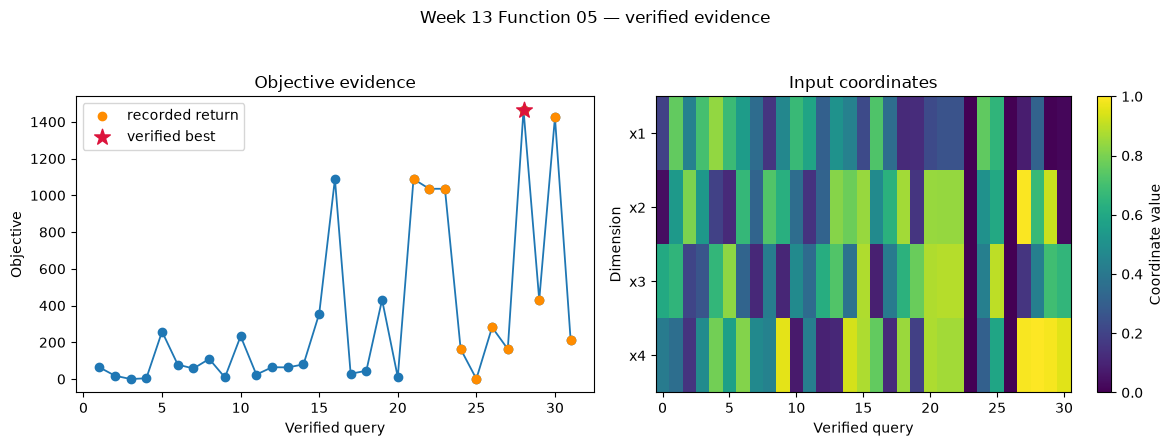

In [2]:
observations,summary,figure=analyse()
summary


<a id="descriptive-eda"></a>
## 6. Descriptive EDA

Inspect a bounded observation preview, full per-variable summary statistics, and the persisted function summary.

In [3]:
display(observations.head(10))
display(observations.describe().T)
display(pd.DataFrame([summary]))

,query,evidence,x1,x2,x3,x4,objective
0,1,starter,0.191447,0.038193,0.607418,0.414584,64.443440
1,2,starter,0.758653,0.536518,0.656000,0.360342,18.301380
2,3,starter,0.438350,0.804340,0.210245,0.151295,0.112940
3,4,starter,0.706051,0.534192,0.264243,0.482088,4.210898
4,5,starter,0.836478,0.193610,0.663893,0.785649,258.370525
5,6,starter,0.683432,0.118663,0.829046,0.567577,78.434389
6,7,starter,0.553621,0.667350,0.323806,0.814870,57.571537
7,8,starter,0.352356,0.322242,0.116979,0.473113,109.571876
8,9,starter,0.153786,0.729382,0.422598,0.443074,8.847992
9,10,starter,0.463442,0.630025,0.107906,0.957644,233.223610


,count,mean,std,min,25%,50%,75%,max
query,31.0,16.000000,9.092121,1.00000,8.500000,16.000000,23.500000,31.000000
x1,31.0,0.379883,0.260460,0.00000,0.172616,0.352356,0.619477,0.836478
x2,31.0,0.523313,0.313149,0.00000,0.255244,0.602894,0.811148,0.992582
x3,31.0,0.499536,0.286463,0.00000,0.294025,0.479592,0.710641,0.898891
x4,31.0,0.558765,0.345607,0.00000,0.248779,0.567577,0.869390,1.000000
objective,31.0,333.086350,450.737549,0.11294,37.024161,109.571876,393.304971,1465.512192


,week,function,dimensions,starter_observations,recorded_pairs,total_verified_observations,best_query,best_input,best_output,latest_verified_query,latest_verified_input,latest_verified_output,latest_improves_previous_best,minimum_output,mean_output,standard_deviation,evidence_gap,interpretation,archive_integrity
0,13,5,4,20,11,31,28,"[0.08123, 0.992582, 0.156202, 0.988421]",1465.512192,31,"[0.016444, 0.027486, 0.656999, 0.955172]",210.038313,False,0.11294,333.08635,443.407995,No verified Week 12 or Week 13 return is prese...,Within-function descriptive evidence; no causa...,Original repository Week 11 arrays remain quar...


<a id="visual-eda"></a>
## 7. Visual EDA

Display the function-level diagnostic figure generated from verified observations.

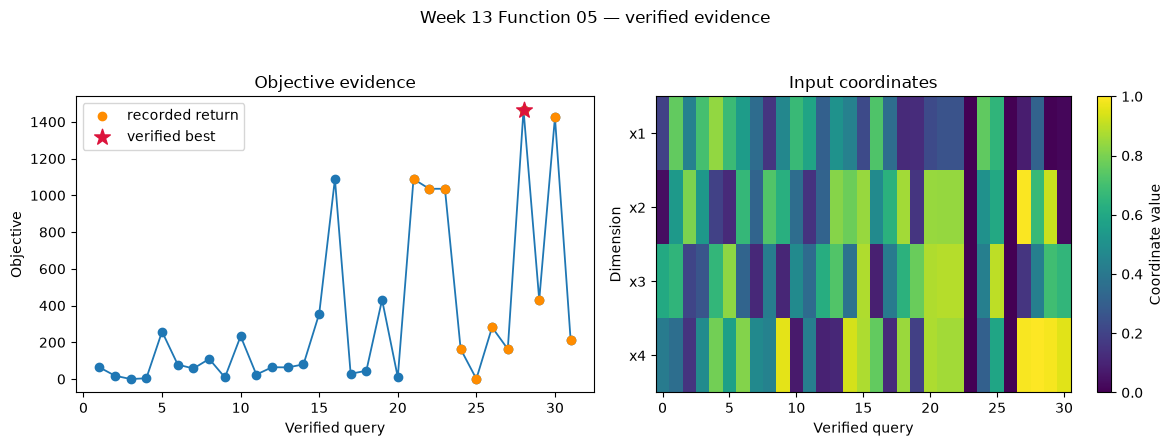

In [4]:
display(figure)

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Load the canonical Week 13 GP-UCB row and expose the fitted kernel, candidate count, kappa, seed, and evidence count.

In [5]:
proposal_ledger = pd.read_csv(repo_root / 'Results' / 'week_13_gp_ucb_proposals.csv')
proposal = proposal_ledger.loc[proposal_ledger['function'].eq(5)].iloc[0]
display(proposal[['observation_count', 'kernel', 'candidate_count', 'kappa', 'random_seed']].to_frame('value'))

,value
observation_count,31
kernel,"1.46**2 * Matern(length_scale=[2, 0.557, 0.756..."
candidate_count,20000
kappa,0.1
random_seed,4205


<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Report the exact portal-formatted query, predicted mean, predictive uncertainty, and acquisition value.

In [6]:
display(proposal[['submission_query', 'predicted_mean', 'predictive_std', 'ucb_score', 'duplicate_at_6dp', 'status']].to_frame('value'))

,value
submission_query,0.099220-0.956522-0.978677-0.993261
predicted_mean,1831.134837
predictive_std,165.074217
ucb_score,1847.642258
duplicate_at_6dp,False
status,validated_proposal_only_week_12_and_13_returns...


<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

Confirm data integrity and consistency between the focused notebook and the canonical proposal ledger.

In [7]:
assert observations.shape[0]==summary['total_verified_observations']
assert observations.filter(regex=r'^x').to_numpy().min()>=0
assert observations.filter(regex=r'^x').to_numpy().max()<=1
assert observations['objective'].notna().all()
print('All Week 13 Function 05 checks passed.')
assert summary['function'] == 5
assert int(proposal['observation_count']) == observations.shape[0]
assert not bool(proposal['duplicate_at_6dp'])
assert float(proposal['kappa']) == 0.1
print('All Week 13 Function 05 workflow checks passed.')

All Week 13 Function 05 checks passed.
All Week 13 Function 05 workflow checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

Summarise the evidence-backed result without promoting a proposal to an observed return.

In [8]:
display(Markdown(f"**Verified observations:** {int(summary['total_verified_observations'])}  \n"f"**Best verified output:** {float(summary['best_output']):.8g}  \n"f"**Week 13 GP-UCB query:** `{proposal['submission_query']}`  \n"f"**UCB score:** {float(proposal['ucb_score']):.8g}  \n""Next step: append this point only after an authoritative returned output is available."))

**Verified observations:** 31  
**Best verified output:** 1465.5122  
**Week 13 GP-UCB query:** `0.099220-0.956522-0.978677-0.993261`  
**UCB score:** 1847.6423  
Next step: append this point only after an authoritative returned output is available.